# 02: Behavioural metrics

Derived purely from the translation run (no DB, no reference query): Pass@1, Pass@k, mean iterations, mean duration, tokens, and cost. Shown per target (Cypher, AQL, Gremlin) in separate sections -- per-model per-query tables, then a per-target aggregation by model -- followed by a run-level summary. Reads every `records_*.json` so it covers the whole matrix; targets are never mixed in one table or figure.

In [10]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "eval"))

import pandas as pd
from harness import METRICS_BEHAVIOURAL_CSV, RECORDS_DIR, billed_input_tokens, load_records, usd_cost

OUT_CSV = METRICS_BEHAVIOURAL_CSV
records = load_records(RECORDS_DIR)
assert records, 'No records found. Run 01_translation_run.ipynb first.'
df = pd.DataFrame(records)
print(f'Loaded {len(df)} records from {RECORDS_DIR}')
from harness import plots

Loaded 168 records from /Users/ivona.obonova/school/rows2graph/rows2graph/eval/outputs/records


## Pricing

USD per million tokens, by provider. Local Ollama is free; the Anthropic rates are Opus-class placeholders -- refine per model when an Anthropic row is added.

In [11]:
# Pricing + cache multipliers live in harness.pricing (usd_cost /
# billed_input_tokens are imported in the first cell) so this notebook,
# notebook 06, and the tests share one source of truth. Anthropic caches the
# system prompt, so cost must price the cache_creation / cache_read buckets,
# not just the uncached input_tokens.
from harness.pricing import (
    CACHE_READ_MULT,
    CACHE_WRITE_MULT,
    MODEL_PRICING,
    PROVIDER_DEFAULT_PRICING,
)

print('Model rates (USD/Mtok, input / output):')
for _m, (_pin, _pout) in MODEL_PRICING.items():
    print(f'  {_m:20} {_pin:>5} / {_pout:>5}')
print('Provider fallback:', PROVIDER_DEFAULT_PRICING)
print(f'Anthropic cache: write x{CACHE_WRITE_MULT}, read x{CACHE_READ_MULT} of the input rate')

Model rates (USD/Mtok, input / output):
  claude-opus-4-8        5.0 /  25.0
  claude-opus-4-7        5.0 /  25.0
  claude-sonnet-4-6      3.0 /  15.0
  claude-haiku-4-5       1.0 /   5.0
  claude-fable-5        10.0 /  50.0
Provider fallback: {'ollama': (0.0, 0.0), 'anthropic': (5.0, 25.0)}
Anthropic cache: write x1.25, read x0.1 of the input rate


## Per-record signals

In [13]:
df['pass_at_1'] = df['validation_passed'] & (df['iterations_used'] == 1)
# Anthropic bills the cached prompt in cache_read / cache_creation; the true
# prompt size (and the platform.claude.com "tokens in") is the sum of all three.
df['billed_input_tokens'] = billed_input_tokens(df['input_tokens'], df['cache_read_tokens'], df['cache_creation_tokens'])
df['cost_usd'] = df.apply(lambda r: usd_cost(
    r['provider'], r['model'], r['input_tokens'], r['output_tokens'],
    r['cache_read_tokens'], r['cache_creation_tokens']), axis=1)

## Per-target results

One section per target, one subsection per model: the model's per-query behavioural signals, then a per-target aggregation by model. `aggregate` is reused by the run-level summary at the end.

In [14]:
MAX_ITERATIONS = int(df['iterations_used'].max()) if len(df) else 0

def aggregate(group):
    successes = group['validation_passed'].sum()
    return pd.Series({
        'n': len(group),
        'pass@1': group['pass_at_1'].mean(),
        f'pass@{MAX_ITERATIONS}': group['validation_passed'].mean(),
        'mean_iterations': group['iterations_used'].mean(),
        'mean_duration_s': group['duration_seconds'].mean(),
        'total_input_tok': int(group['billed_input_tokens'].sum()),
        'total_uncached_input_tok': int(group['input_tokens'].sum()),
        'total_output_tok': int(group['output_tokens'].sum()),
        'total_cost_usd': group['cost_usd'].sum(),
        'cost_per_success_usd': group['cost_usd'].sum() / successes if successes else float('nan'),
    })

MODEL_COLS = ['query_id', 'difficulty', 'validation_passed', 'pass_at_1', 'iterations_used',
              'duration_seconds', 'billed_input_tokens', 'output_tokens', 'cost_usd']

def show_model(target, model):
    """Per-query behavioural signals for one (target, model) cell."""
    sub = df[(df['target'] == target) & (df['model'] == model)]
    if not len(sub):
        print(f'No records for {target}/{model} yet.')
        return None
    return sub[MODEL_COLS].sort_values('query_id').reset_index(drop=True)

def summarize_target(target):
    """Aggregate one target's records by model."""
    sub = df[df['target'] == target]
    if not len(sub):
        print(f'No records for {target} yet.')
        return None
    return sub.groupby('model').apply(aggregate)

## SQL → Cypher

### llama3.2:latest

In [15]:
show_model('cypher', 'llama3.2:latest')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,6.945831,2404,35,0.0
1,ldbc_q02,easy,True,False,3,13.532050,8910,162,0.0
2,ldbc_q03,easy,True,True,1,8.171838,2401,185,0.0
3,ldbc_q04,hard,True,True,1,9.199575,3172,193,0.0
4,ldbc_q05,hard,True,True,1,4.061995,3461,81,0.0
5,ldbc_q06,medium,True,True,1,3.304163,2732,69,0.0
6,ldbc_q07,medium,True,True,1,5.110439,3199,104,0.0
7,ldbc_q08,hard,True,False,3,20.374309,9238,421,0.0
8,ldbc_q09,medium,True,True,1,3.901266,2821,85,0.0
9,ldbc_q10,hard,True,True,1,8.464310,3173,181,0.0


### qwen3-coder:30b

In [16]:
show_model('cypher', 'qwen3-coder:30b')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,17.392788,2406,31,0.0
1,ldbc_q02,easy,True,True,1,19.496970,2890,71,0.0
2,ldbc_q03,easy,True,True,1,1.185505,2401,22,0.0
3,ldbc_q04,hard,True,True,1,3.422444,3175,49,0.0
4,ldbc_q05,hard,True,True,1,4.775432,3464,83,0.0
5,ldbc_q06,medium,True,True,1,3.332481,2734,47,0.0
6,ldbc_q07,medium,True,True,1,5.407516,3232,98,0.0
7,ldbc_q08,hard,True,True,1,5.113587,2841,93,0.0
8,ldbc_q09,medium,True,True,1,3.474695,2831,65,0.0
9,ldbc_q10,hard,True,True,1,4.065331,3175,42,0.0


### gemma4:26b

In [17]:
show_model('cypher', 'gemma4:26b')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,37.736048,2735,422,0.0
1,ldbc_q02,easy,True,True,1,56.467919,3262,1215,0.0
2,ldbc_q03,easy,True,True,1,5.185734,2730,415,0.0
3,ldbc_q04,hard,True,True,1,12.430539,3563,1024,0.0
4,ldbc_q05,hard,True,True,1,24.740709,3864,2099,0.0
5,ldbc_q06,medium,True,True,1,15.012691,3094,1236,0.0
6,ldbc_q07,medium,True,True,1,22.617156,3642,1904,0.0
7,ldbc_q08,hard,True,True,1,24.555018,3222,2134,0.0
8,ldbc_q09,medium,True,True,1,23.373235,3203,2013,0.0
9,ldbc_q10,hard,True,True,1,10.780821,3566,828,0.0


### claude-opus-4-8

In [18]:
show_model('cypher', 'claude-opus-4-8')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,2.084392,3825,50,0.025085
1,ldbc_q02,easy,True,True,1,7.168288,4566,87,0.030624
2,ldbc_q03,easy,True,True,1,1.633420,3823,45,0.003284
3,ldbc_q04,hard,True,True,1,2.711763,5186,76,0.034169
4,ldbc_q05,hard,True,True,1,2.775870,5709,96,0.037882
5,ldbc_q06,medium,True,True,1,2.871345,4385,73,0.029084
6,ldbc_q07,medium,True,True,1,2.847695,5152,140,0.035502
7,ldbc_q08,hard,True,True,1,2.855862,4592,151,0.032151
8,ldbc_q09,medium,True,True,1,3.690251,4572,118,0.031371
9,ldbc_q10,hard,True,True,1,2.324540,5188,89,0.005346


### Visualizations

SQL -> Cypher: 4 model(s), 14 query id(s)


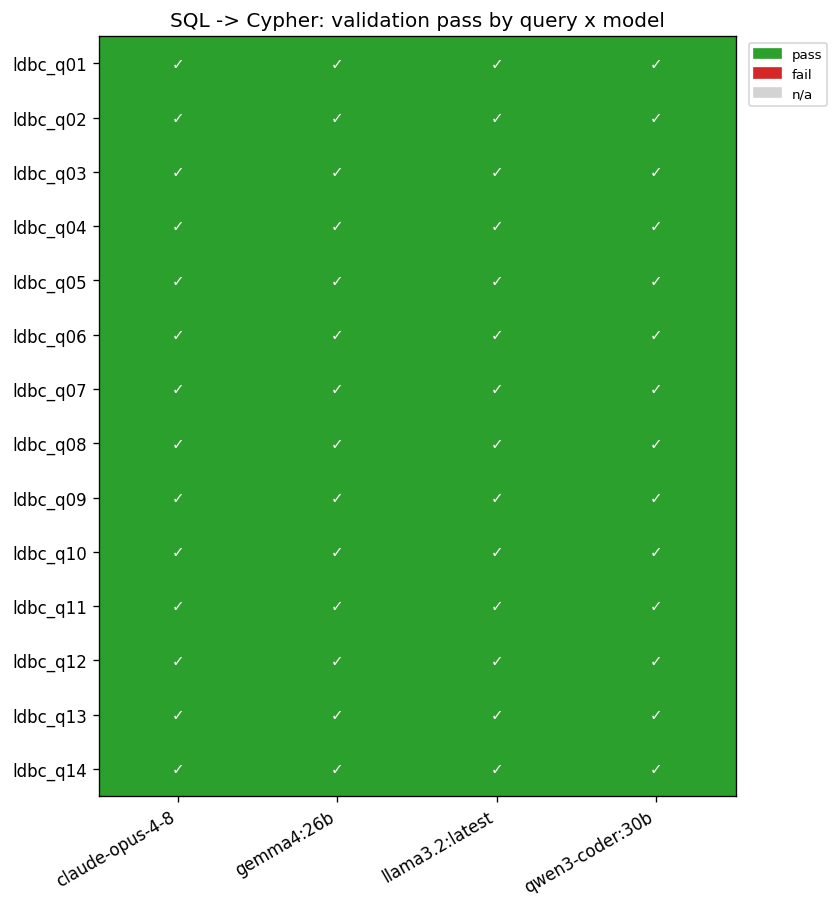

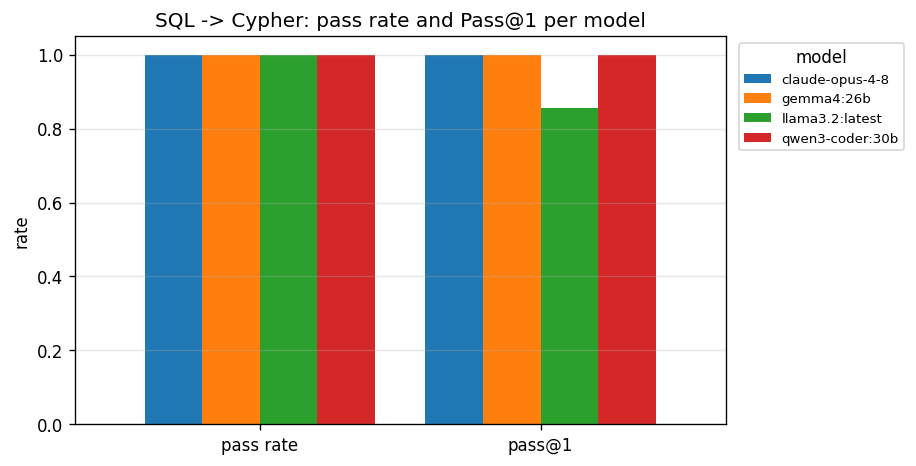

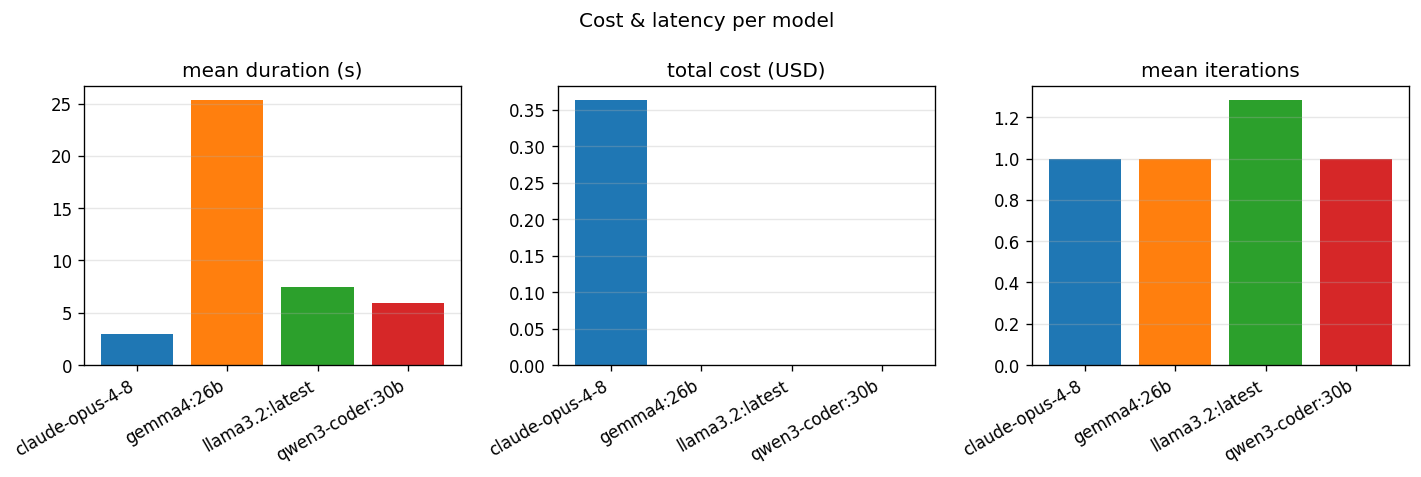

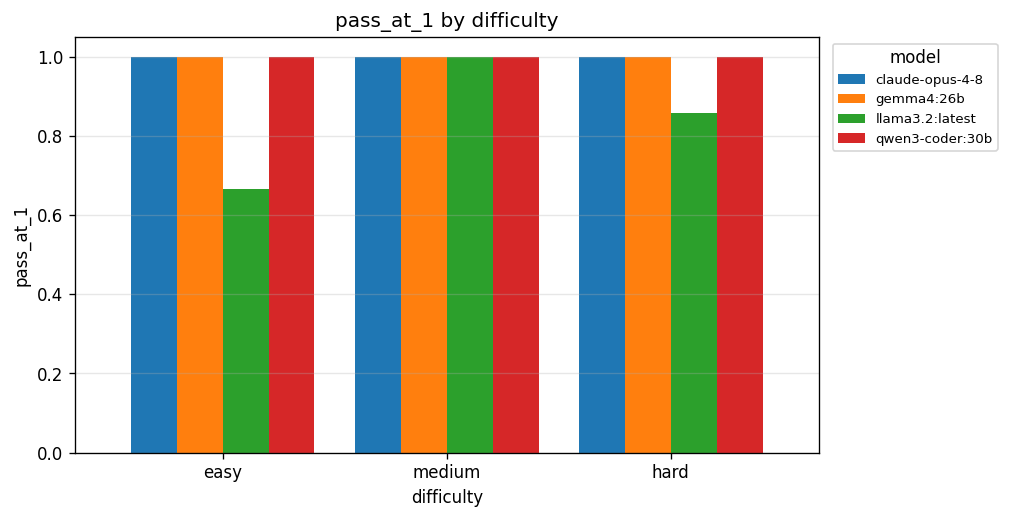

In [33]:
plots.render_target(df[df['target'] == 'cypher'], 'cypher', 'SQL -> Cypher', plots.FIGURE_SETS['behavioural'])

### Aggregation by model

In [19]:
summarize_target('cypher')

,n,pass@1,pass@3,mean_iterations,mean_duration_s,total_input_tok,total_uncached_input_tok,total_output_tok,total_cost_usd,cost_per_success_usd
model,,,,,,,,,,
claude-opus-4-8,14.0,1.000000,1.0,1.000000,2.982038,66040.0,1734.0,1329.0,0.363825,0.025988
gemma4:26b,14.0,1.000000,1.0,1.000000,25.378478,46127.0,46127.0,23720.0,0.000000,0.000000
llama3.2:latest,14.0,0.857143,1.0,1.285714,7.469851,53254.0,53254.0,1955.0,0.000000,0.000000
qwen3-coder:30b,14.0,1.000000,1.0,1.000000,5.933367,40910.0,40910.0,833.0,0.000000,0.000000


## SQL → AQL

### llama3.2:latest

In [20]:
show_model('aql', 'llama3.2:latest')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,10.834274,3084,110,0.0
1,ldbc_q02,easy,True,True,1,8.007973,3412,163,0.0
2,ldbc_q03,easy,True,True,1,5.935551,3081,124,0.0
3,ldbc_q04,hard,True,False,2,16.883880,8603,329,0.0
4,ldbc_q05,hard,True,False,2,17.596494,9219,333,0.0
5,ldbc_q06,medium,True,True,1,9.611270,3462,198,0.0
6,ldbc_q07,medium,True,True,1,10.314666,3806,213,0.0
7,ldbc_q08,hard,True,False,3,37.362195,12952,746,0.0
8,ldbc_q09,medium,False,False,3,23.329497,11500,465,0.0
9,ldbc_q10,hard,True,False,2,28.752213,8779,555,0.0


### qwen3-coder:30b

In [21]:
show_model('aql', 'qwen3-coder:30b')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,18.903891,3088,49,0.0
1,ldbc_q02,easy,True,True,1,3.055459,3441,61,0.0
2,ldbc_q03,easy,True,True,1,1.827960,3083,35,0.0
3,ldbc_q04,hard,True,True,1,6.200545,4018,88,0.0
4,ldbc_q05,hard,True,True,1,5.246304,4334,93,0.0
5,ldbc_q06,medium,True,True,1,4.275656,3466,55,0.0
6,ldbc_q07,medium,True,True,1,6.019845,3835,104,0.0
7,ldbc_q08,hard,True,True,1,6.641182,3601,113,0.0
8,ldbc_q09,medium,True,True,1,4.078746,3623,79,0.0
9,ldbc_q10,hard,True,True,1,4.485285,4018,51,0.0


### gemma4:26b

In [22]:
show_model('aql', 'gemma4:26b')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,21.159219,3441,453,0.0
1,ldbc_q02,easy,True,True,1,14.435183,3818,1225,0.0
2,ldbc_q03,easy,True,True,1,5.401434,3436,429,0.0
3,ldbc_q04,hard,True,True,1,24.457997,4432,1981,0.0
4,ldbc_q05,hard,True,True,1,72.695676,4764,6385,0.0
5,ldbc_q06,medium,True,True,1,22.087202,3856,1801,0.0
6,ldbc_q07,medium,True,True,1,26.812581,4258,2302,0.0
7,ldbc_q08,hard,True,False,2,133.419983,8617,11571,0.0
8,ldbc_q09,medium,True,True,1,64.891218,4026,5565,0.0
9,ldbc_q10,hard,True,True,1,18.305811,4435,1447,0.0


### claude-opus-4-8

In [23]:
show_model('aql', 'claude-opus-4-8')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,3.278285,5049,77,0.033410
1,ldbc_q02,easy,True,True,1,2.613209,5619,80,0.037030
2,ldbc_q03,easy,True,True,1,4.596436,5047,62,0.004321
3,ldbc_q04,hard,True,True,1,2.334190,6693,104,0.044288
4,ldbc_q05,hard,True,True,1,3.771293,7275,212,0.050570
5,ldbc_q06,medium,True,True,1,2.337970,5682,100,0.037865
6,ldbc_q07,medium,True,True,1,2.853055,6278,142,0.042590
7,ldbc_q08,hard,True,True,1,2.959778,5944,216,0.042226
8,ldbc_q09,medium,True,True,1,2.539799,5971,142,0.040716
9,ldbc_q10,hard,True,True,1,2.238497,6695,95,0.006249


### Visualizations

SQL -> AQL: 4 model(s), 14 query id(s)


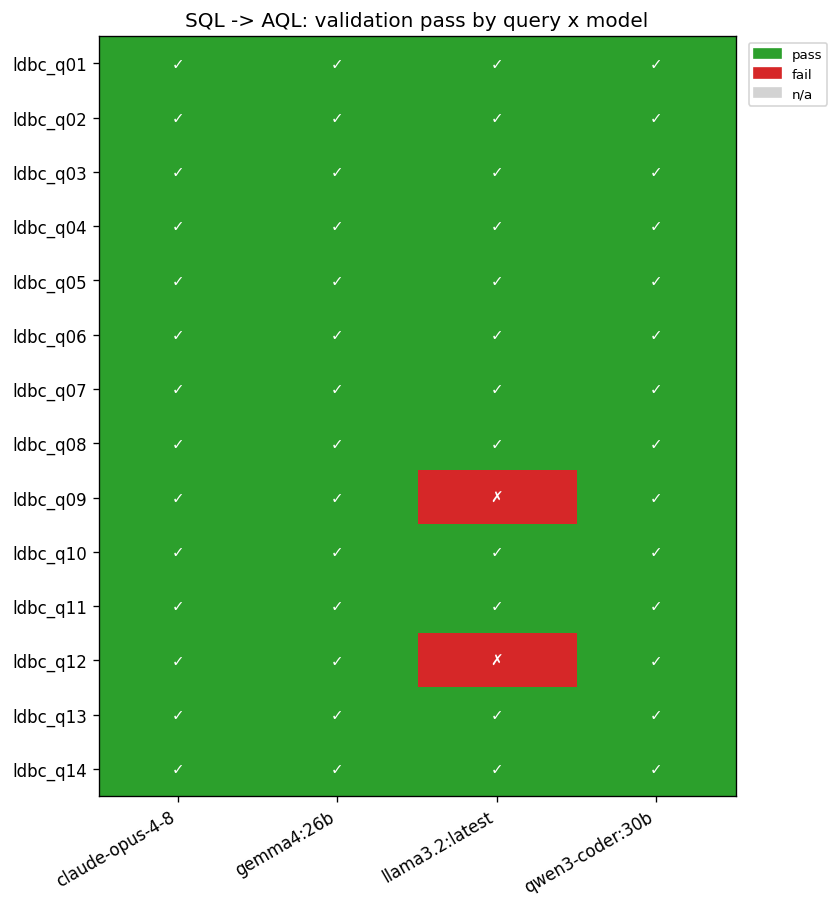

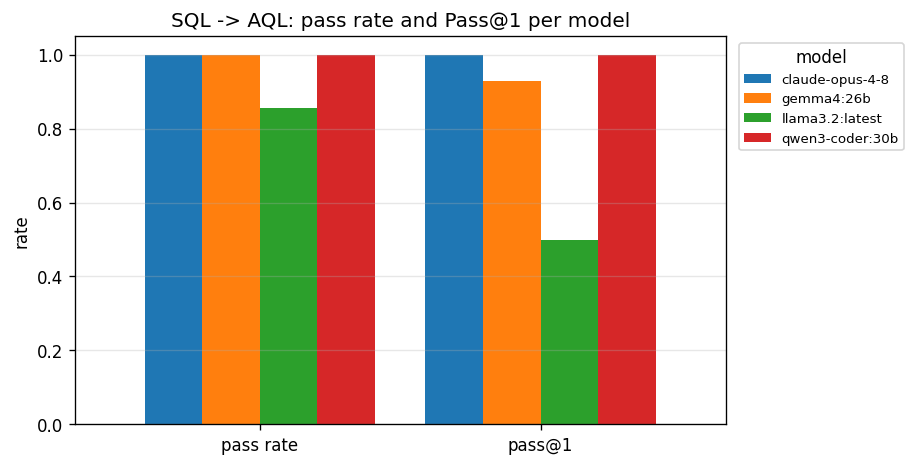

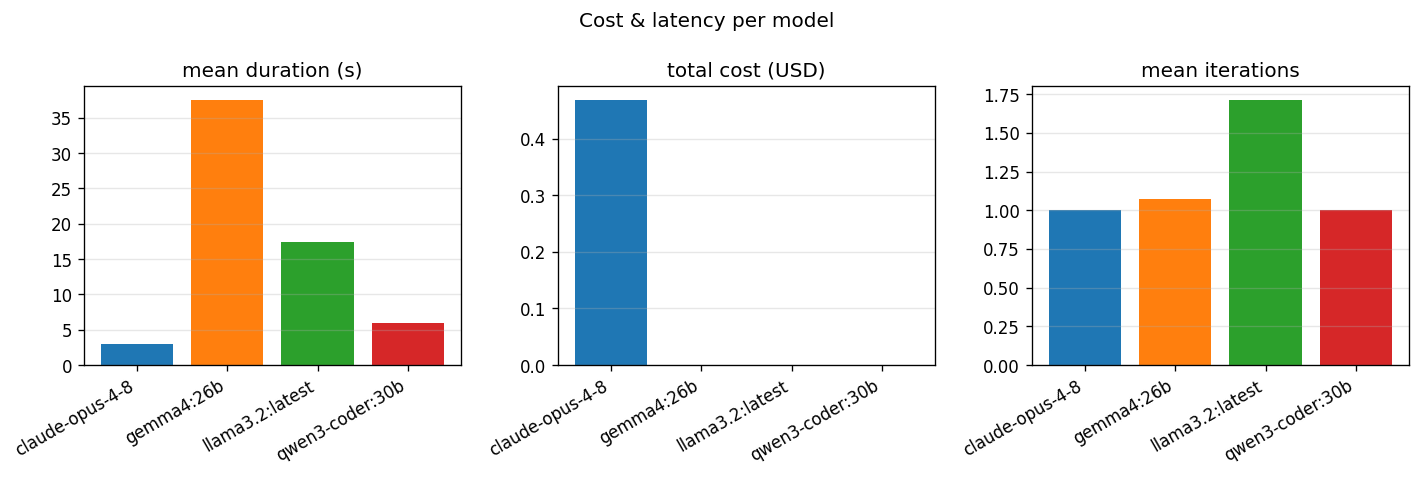

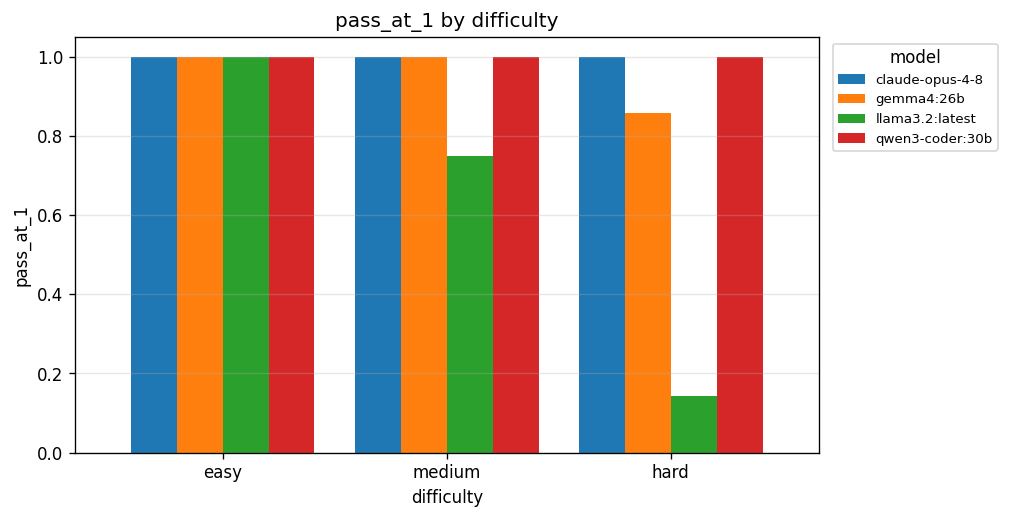

In [34]:
plots.render_target(df[df['target'] == 'aql'], 'aql', 'SQL -> AQL', plots.FIGURE_SETS['behavioural'])

### Aggregation by model

In [24]:
summarize_target('aql')

,n,pass@1,pass@3,mean_iterations,mean_duration_s,total_input_tok,total_uncached_input_tok,total_output_tok,total_cost_usd,cost_per_success_usd
model,,,,,,,,,,
claude-opus-4-8,14.0,1.000000,1.000000,1.000000,2.937807,84841.0,1733.0,1802.0,0.468789,0.033485
gemma4:26b,14.0,0.928571,1.000000,1.071429,37.575766,61532.0,61532.0,43420.0,0.000000,0.000000
llama3.2:latest,14.0,0.500000,0.857143,1.714286,17.379367,96810.0,96810.0,4716.0,0.000000,0.000000
qwen3-coder:30b,14.0,1.000000,1.000000,1.000000,5.920778,51364.0,51364.0,1049.0,0.000000,0.000000


## SQL → Gremlin

### llama3.2:latest

In [25]:
show_model('gremlin', 'llama3.2:latest')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,13.159977,2671,184,0.0
1,ldbc_q02,easy,False,False,3,30.228762,9857,662,0.0
2,ldbc_q03,easy,True,True,1,7.280943,2668,164,0.0
3,ldbc_q04,hard,False,False,3,36.715658,11898,725,0.0
4,ldbc_q05,hard,False,False,3,41.049272,12070,820,0.0
5,ldbc_q06,medium,False,False,3,17.293283,9717,369,0.0
6,ldbc_q07,medium,False,False,3,36.326841,11101,758,0.0
7,ldbc_q08,hard,True,True,1,32.553665,3183,698,0.0
8,ldbc_q09,medium,False,False,3,37.760254,11551,792,0.0
9,ldbc_q10,hard,False,False,3,29.893580,11047,613,0.0


### qwen3-coder:30b

In [26]:
show_model('gremlin', 'qwen3-coder:30b')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,11.609653,2675,56,0.0
1,ldbc_q02,easy,True,True,1,2.872458,2992,72,0.0
2,ldbc_q03,easy,True,True,1,1.913921,2670,41,0.0
3,ldbc_q04,hard,True,False,3,18.067965,10842,340,0.0
4,ldbc_q05,hard,True,True,1,5.568143,3670,109,0.0
5,ldbc_q06,medium,True,True,1,3.427081,3045,58,0.0
6,ldbc_q07,medium,True,True,1,4.488420,3377,93,0.0
7,ldbc_q08,hard,False,False,1,NaN,0,0,0.0
8,ldbc_q09,medium,True,True,1,5.338304,3203,108,0.0
9,ldbc_q10,hard,True,True,1,5.841224,3387,94,0.0


### gemma4:26b

In [27]:
show_model('gremlin', 'gemma4:26b')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,24.769073,2998,1239,0.0
1,ldbc_q02,easy,True,True,1,10.268602,3322,829,0.0
2,ldbc_q03,easy,True,True,1,8.568272,2993,697,0.0
3,ldbc_q04,hard,True,True,1,23.684939,3758,1962,0.0
4,ldbc_q05,hard,True,True,1,58.420987,4055,5006,0.0
5,ldbc_q06,medium,True,True,1,28.340513,3393,2372,0.0
6,ldbc_q07,medium,True,True,1,34.905015,3738,2995,0.0
7,ldbc_q08,hard,True,True,1,50.942750,3556,3696,0.0
8,ldbc_q09,medium,True,True,1,63.552989,3570,4642,0.0
9,ldbc_q10,hard,True,True,1,35.526123,3761,2985,0.0


### claude-opus-4-8

In [28]:
show_model('gremlin', 'claude-opus-4-8')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,2.570988,4127,76,0.027623
1,ldbc_q02,easy,True,True,1,1.942554,4571,85,0.030605
2,ldbc_q03,easy,True,True,1,2.109440,4125,61,0.003835
3,ldbc_q04,hard,True,True,1,2.800566,5261,78,0.034688
4,ldbc_q05,hard,True,True,1,4.037739,5724,78,0.037526
5,ldbc_q06,medium,True,True,1,2.037096,4683,81,0.031146
6,ldbc_q07,medium,True,True,1,4.283523,5153,186,0.036659
7,ldbc_q08,hard,True,True,1,4.017482,4926,141,0.033989
8,ldbc_q09,medium,True,True,1,3.045629,4933,157,0.034604
9,ldbc_q10,hard,True,True,1,2.142205,5263,73,0.004983


### Visualizations

SQL -> Gremlin: 4 model(s), 14 query id(s)


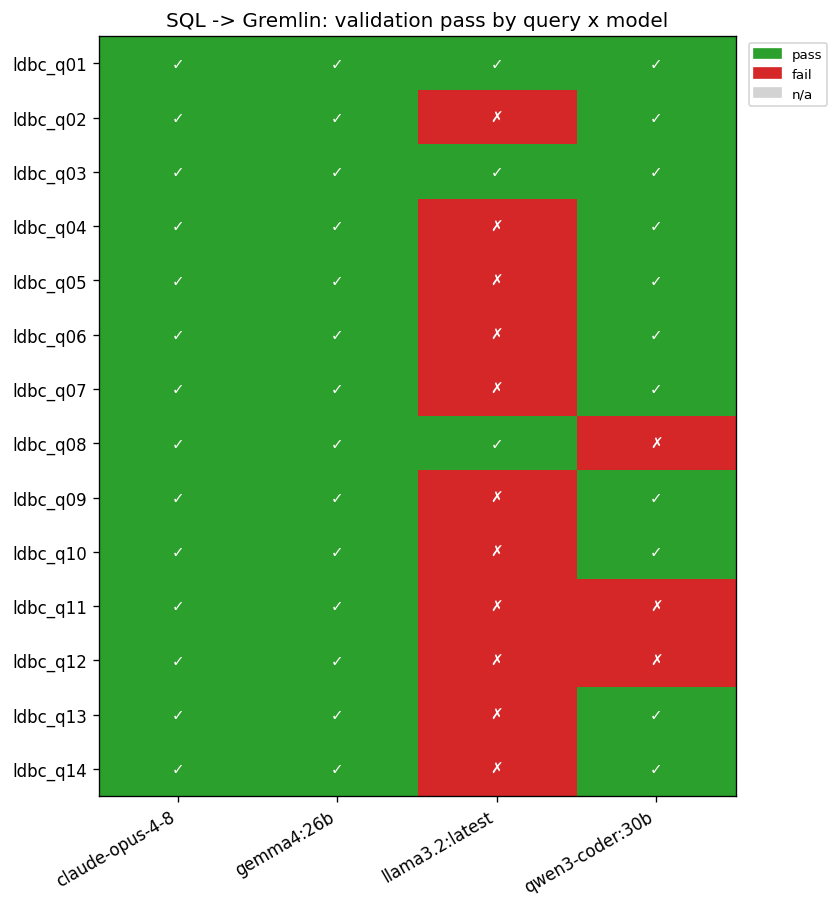

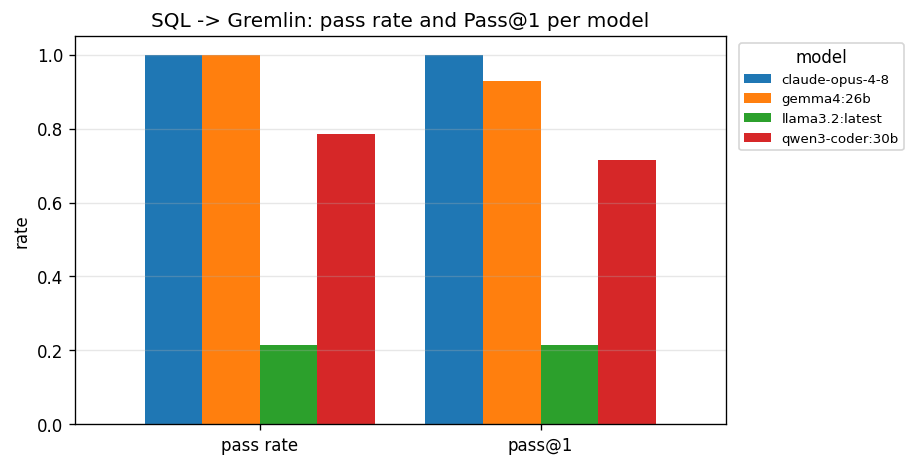

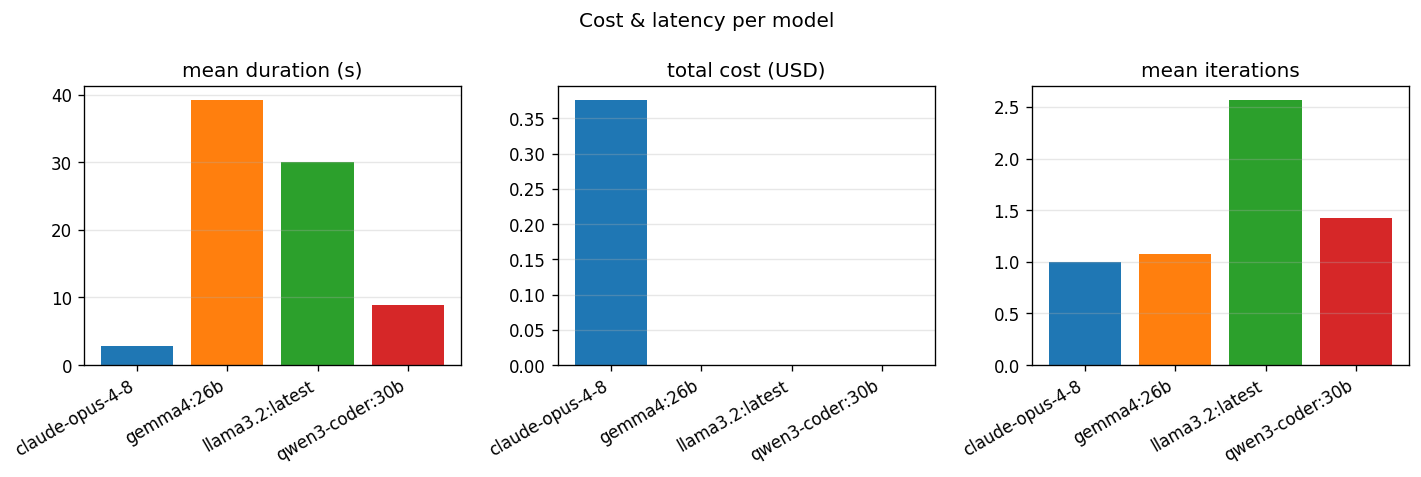

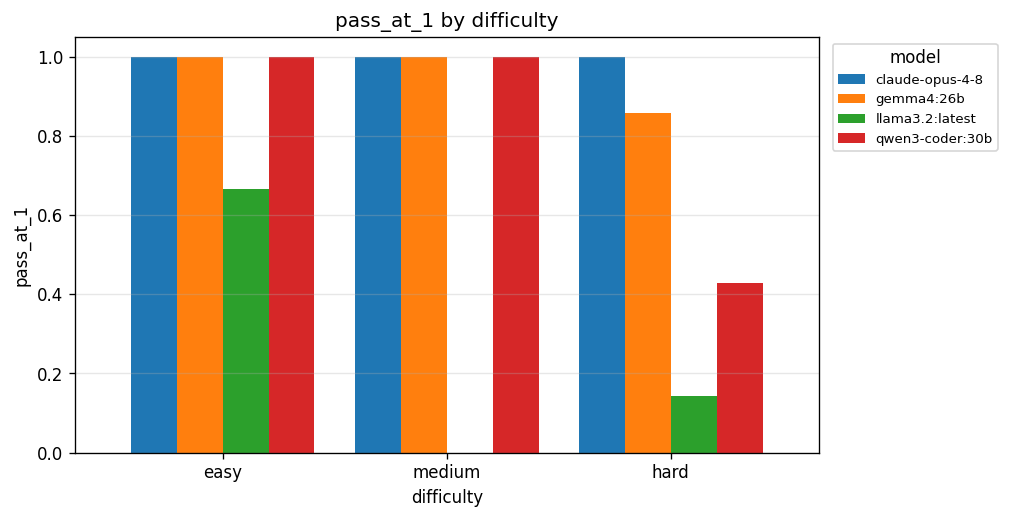

In [35]:
plots.render_target(df[df['target'] == 'gremlin'], 'gremlin', 'SQL -> Gremlin', plots.FIGURE_SETS['behavioural'])

### Aggregation by model

In [29]:
summarize_target('gremlin')

,n,pass@1,pass@3,mean_iterations,mean_duration_s,total_input_tok,total_uncached_input_tok,total_output_tok,total_cost_usd,cost_per_success_usd
model,,,,,,,,,,
claude-opus-4-8,14.0,1.000000,1.000000,1.000000,2.779905,68470.0,1733.0,1341.0,0.376715,0.026908
gemma4:26b,14.0,0.928571,1.000000,1.071429,39.254438,53359.0,53359.0,44454.0,0.000000,0.000000
llama3.2:latest,14.0,0.214286,0.214286,2.571429,30.037370,127989.0,127989.0,8685.0,0.000000,0.000000
qwen3-coder:30b,14.0,0.714286,0.785714,1.428571,8.829270,64911.0,64911.0,2006.0,0.000000,0.000000


## Run-level summary

The whole matrix at a glance: the overall aggregate, the per-cell (dataset x target x model) table, and the difficulty stratification.

In [30]:
print('Overall:')
display(aggregate(df).to_frame('overall').T)

print('By dataset x target x model:')
display(df.groupby(['dataset','target','model'], group_keys=False).apply(aggregate))

print('By target x difficulty:')
_by_diff = df.copy()
_by_diff['difficulty'] = pd.Categorical(_by_diff['difficulty'], ['easy', 'medium', 'hard'], ordered=True)
display(_by_diff.groupby(['target', 'difficulty'], group_keys=False, observed=True).apply(aggregate))

Overall:


,n,pass@1,pass@3,mean_iterations,mean_duration_s,total_input_tok,total_uncached_input_tok,total_output_tok,total_cost_usd,cost_per_success_usd
overall,168.0,0.845238,0.904762,1.261905,15.580053,815607.0,601456.0,135310.0,1.209329,0.007956


By dataset x target x model:


n    pass@1    pass@3  mean_iterations  \
dataset target  model                                                        
ldbc    aql     claude-opus-4-8  14.0  1.000000  1.000000         1.000000   
                gemma4:26b       14.0  0.928571  1.000000         1.071429   
                llama3.2:latest  14.0  0.500000  0.857143         1.714286   
                qwen3-coder:30b  14.0  1.000000  1.000000         1.000000   
        cypher  claude-opus-4-8  14.0  1.000000  1.000000         1.000000   
                gemma4:26b       14.0  1.000000  1.000000         1.000000   
                llama3.2:latest  14.0  0.857143  1.000000         1.285714   
                qwen3-coder:30b  14.0  1.000000  1.000000         1.000000   
        gremlin claude-opus-4-8  14.0  1.000000  1.000000         1.000000   
                gemma4:26b       14.0  0.928571  1.000000         1.071429   
                llama3.2:latest  14.0  0.214286  0.214286         2.571429   
                qwen3-coder:30b  14.0  0.714286  0.785714         1.428571   

                                 mean_duration_s  total_input_tok  \
dataset target  model                                               
ldbc    aql     claude-opus-4-8         2.937807          84841.0   
                gemma4:26b             37.575766          61532.0   
                llama3.2:latest        17.379367          96810.0   
                qwen3-coder:30b         5.920778          51364.0   
        cypher  claude-opus-4-8         2.982038          66040.0   
                gemma4:26b             25.378478          46127.0   
                llama3.2:latest         7.469851          53254.0   
                qwen3-coder:30b         5.933367          40910.0   
        gremlin claude-opus-4-8         2.779905          68470.0   
                gemma4:26b             39.254438          53359.0   
                llama3.2:latest        30.037370         127989.0   
                qwen3-coder:30b         8.829270          64911.0   

                                 total_uncached_input_tok  total_output_tok  \
dataset target  model                                                         
ldbc    aql     claude-opus-4-8                    1733.0            1802.0   
                gemma4:26b                        61532.0           43420.0   
                llama3.2:latest                   96810.0            4716.0   
                qwen3-coder:30b                   51364.0            1049.0   
        cypher  claude-opus-4-8                    1734.0            1329.0   
                gemma4:26b                        46127.0           23720.0   
                llama3.2:latest                   53254.0            1955.0   
                qwen3-coder:30b                   40910.0             833.0   
        gremlin claude-opus-4-8                    1733.0            1341.0   
                gemma4:26b                        53359.0           44454.0   
                llama3.2:latest                  127989.0            8685.0   
                qwen3-coder:30b                   64911.0            2006.0   

                                 total_cost_usd  cost_per_success_usd  
dataset target  model                                                  
ldbc    aql     claude-opus-4-8        0.468789              0.033485  
                gemma4:26b             0.000000              0.000000  
                llama3.2:latest        0.000000              0.000000  
                qwen3-coder:30b        0.000000              0.000000  
        cypher  claude-opus-4-8        0.363825              0.025988  
                gemma4:26b             0.000000              0.000000  
                llama3.2:latest        0.000000              0.000000  
                qwen3-coder:30b        0.000000              0.000000  
        gremlin claude-opus-4-8        0.376715              0.026908  
                gemma4:26b             0.000000              0.000000  
     

By target x difficulty:


n    pass@1    pass@3  mean_iterations  \
target  difficulty                                              
aql     easy        12.0  1.000000  1.000000         1.000000   
        medium      16.0  0.937500  0.937500         1.125000   
        hard        28.0  0.750000  0.964286         1.321429   
cypher  easy        12.0  0.916667  1.000000         1.166667   
        medium      16.0  1.000000  1.000000         1.000000   
        hard        28.0  0.964286  1.000000         1.071429   
gremlin easy        12.0  0.916667  0.916667         1.166667   
        medium      16.0  0.750000  0.750000         1.500000   
        hard        28.0  0.607143  0.678571         1.678571   

                    mean_duration_s  total_input_tok  \
target  difficulty                                     
aql     easy               8.337406          45599.0   
        medium            13.746157          78144.0   
        hard              20.478738         170804.0   
cypher  easy              14.750065          42353.0   
        medium             8.003245          56201.0   
        hard               9.987127         107777.0   
gremlin easy               9.774554          45669.0   
        medium            21.615009          89996.0   
        hard              24.468507         179064.0   

                    total_uncached_input_tok  total_output_tok  \
target  difficulty                                               
aql     easy                         30067.0            2868.0   
        medium                       54318.0           13107.0   
        hard                        127054.0           35012.0   
cypher  easy                         30322.0            2740.0   
        medium                       37602.0            7611.0   
        hard                         74101.0           17486.0   
gremlin easy                         33029.0            4166.0   
        medium                       70725.0           18829.0   
        hard                        144238.0           33491.0   

                    total_cost_usd  cost_per_success_usd  
target  difficulty                                        
aql     easy              0.074761              0.006230  
        medium            0.163582              0.010906  
        hard              0.230445              0.008535  
cypher  easy              0.058993              0.004916  
        medium            0.128969              0.008061  
        hard              0.175864              0.006281  
gremlin easy              0.062062              0.005642  
        medium            0.134839              0.011237  
        hard              0.179813              0.009464

## Save per-record CSV

In [31]:
out = df[['dataset','target','model','provider','query_id','difficulty',
          'validation_passed','pass_at_1','iterations_used','duration_seconds',
          'input_tokens','output_tokens','cache_read_tokens','cache_creation_tokens',
          'billed_input_tokens','cost_usd']].copy()
out.to_csv(OUT_CSV, index=False)
print(f'Wrote {len(out)} rows to {OUT_CSV}')

Wrote 168 rows to /Users/ivona.obonova/school/rows2graph/rows2graph/eval/outputs/metrics/metrics_behavioural.csv
